# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [19]:

x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

# Calculate - See pages 100 - 104
mean = x.mean(dim=-1, keepdim=True) # Expect something ~0
variance = x.var(dim=-1, unbiased=False, keepdim=True) # Expect something ~1
standard_deviation = x.std(dim=-1, unbiased=False, keepdim=True) # Expect something ~1
normalized_output = (x - mean) / (standard_deviation)

In [20]:
# Verify with
normalized_output.mean(dim=-1)

tensor([0., 0.])

In [21]:
normalized_output.var(dim=-1, unbiased=False)



tensor([1.0000, 1.0000])

## Section 3: Exploring GELU
Compare ReLU and GELU

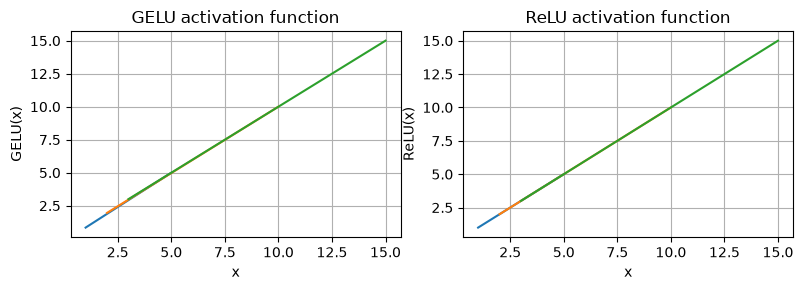

In [22]:
# Use this and plot both
torch.linspace(-4, 4, 100)
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))
gelu, relu = GELU(), nn.ReLU()

y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [23]:
# Create
input_shape = (2, 3, 768)

In [24]:
x = torch.randn(input_shape)
# Pass through 
#  Linear - Expect (2,3,768)
linear = nn.Linear(768, 3072)
x = linear(x)
#  GELU - Expect (2,3,3072)
gelu = GELU()
x = gelu(x)
#  Linear again - Expect (2,3,768) again
linear2 = nn.Linear(3072, 768)
x = linear2(x)

print(f"Output shape: {x.shape}")

Output shape: torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [26]:
x = torch.randn(2, 3, 768)
layer = nn.Linear(768, 768)  # toy layer, same in/out shape so addition works

# Without residual
output_no_residual = layer(x)

# With residual
output_with_residual = x + layer(x)

print(f"Output shape without residual: {output_no_residual.shape}")
print(f"Output shape with residual: {output_with_residual.shape}")

Output shape without residual: torch.Size([2, 3, 768])
Output shape with residual: torch.Size([2, 3, 768])


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output